## Peak performance comparison between Multi-Cube Scan 

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [14]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128]

In [15]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [ ]:
df_baseline = pd.read_csv(f"../../bench_results_copy_{dtype}.csv")
df_baseline["S"] = "copy"
add_stats_siso(df_baseline, 2)

df_scan = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"../../bench_results_mcscan_{tile}_{dtype}.csv")
    df_tmp["S"] = f"MCSCAN ({tile})"
    df_scan = pd.concat([df_scan, df_tmp])

for tile in tiles:
    df_tmp = pd.read_csv(f"../../bench_results_scan_multi_cube_{tile}_{dtype}.csv")
    df_tmp["S"] = f"MC-SCANUL1 ({tile})"
    df_scan = pd.concat([df_scan, df_tmp])


add_stats_siso(df_scan, 4)

df = pd.concat([df_baseline, df_scan])

## Paper plots

/tmp/ipykernel_614840/3668118024.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


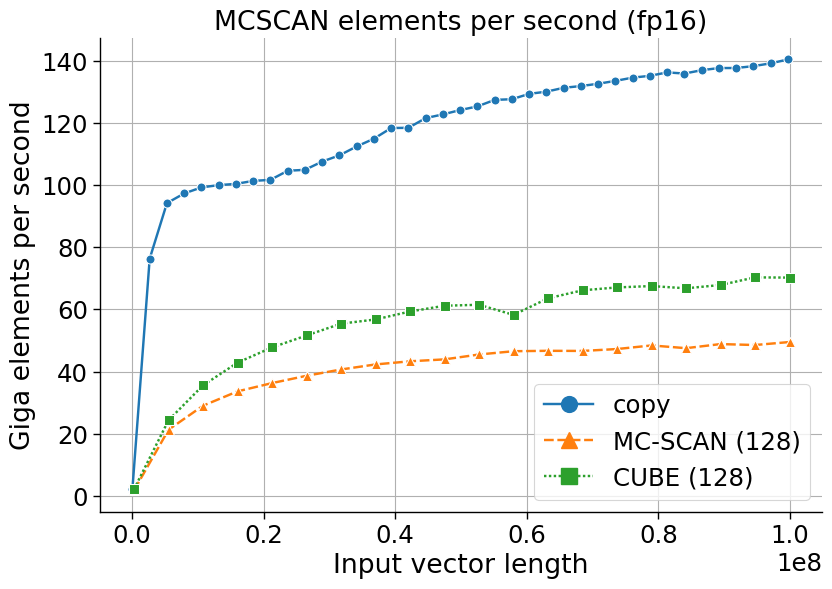

<Figure size 870x627 with 0 Axes>

In [17]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_614840/302085082.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


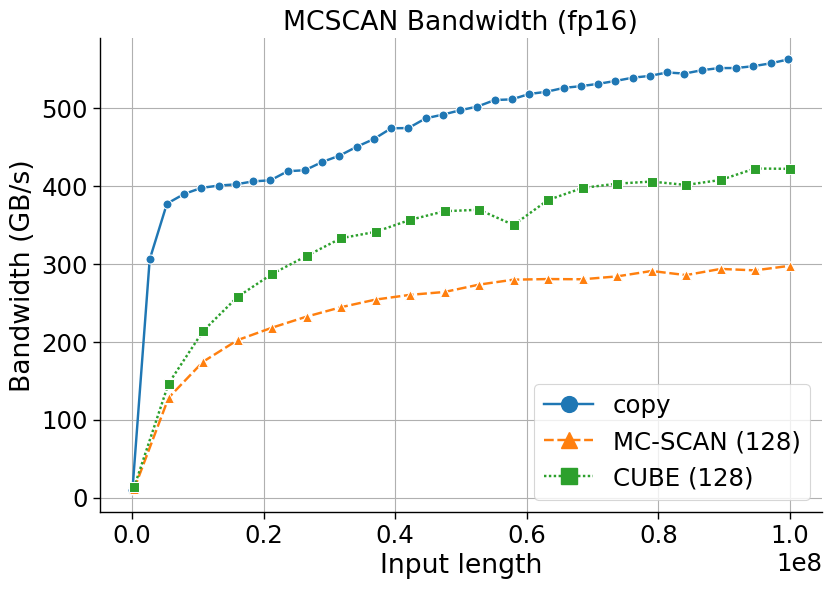

<Figure size 870x627 with 0 Axes>

In [18]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_bw_{dtype}.png")
plt.show()
plt.clf()
